In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

VINHO = "#722F37"
VINHO_CLARO = "#B76E79"
VINHO_ESCURO = "#4A1720"
ROSE = "#D8A0A6"

sns.set_theme(style="white")


In [2]:
# Carregamento do dataset em formato CSV
df = pd.read_csv("../data/WineQT.csv")

print(f"Dimensões da base: {df.shape}")
display(df.head())


Dimensões da base: (1143, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


| Nova variável     | Fórmula                          | Justificativa                                 |
| ----------------- | -------------------------------- | --------------------------------------------- |
| sulfur_ratio      | free SO₂ / total SO₂             | Representa a proporção de enxofre livre       |
| acidity_ratio     | fixed acidity / volatile acidity | Mede o equilíbrio entre acidez fixa e volátil |
| alcohol_density   | alcohol / density                | Relaciona teor alcoólico e densidade          |
| total_acidity     | fixed acidity + citric acid      | Indicador geral de acidez                     |
| sulfur_difference | total SO₂ − free SO₂             | Quantifica o enxofre combinado                |
| alcohol_per_sugar | alcohol / residual sugar         | Relação entre álcool e açúcar residual        |


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [4]:
df.shape

(1143, 13)

In [5]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


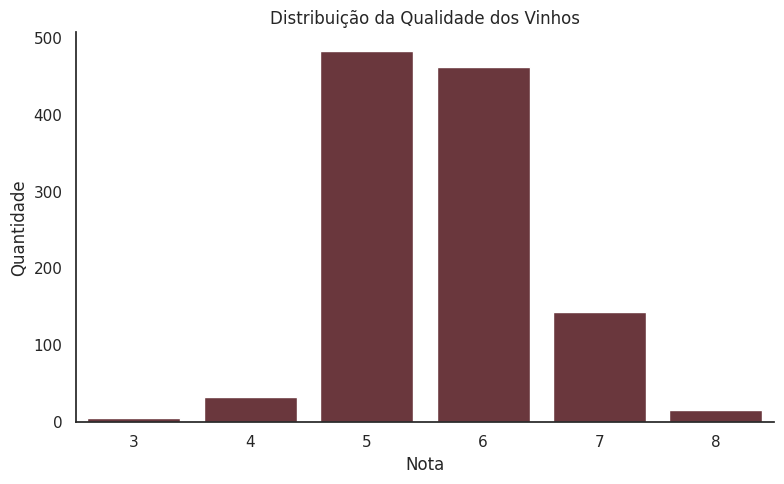

In [8]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="quality",
    color=VINHO
)

plt.title("Distribuição da Qualidade dos Vinhos")
plt.xlabel("Nota")
plt.ylabel("Quantidade")
sns.despine()
plt.tight_layout()
plt.show()


## Transformação da variável-alvo

A variável `quality` será convertida em uma classificação binária:
- **0:** baixa/média qualidade (`quality < 7`)
- **1:** alta qualidade (`quality >= 7`)


In [9]:
df["quality_binary"] = (df["quality"] >= 7).astype(int)

df["quality_binary"].value_counts()

,count
quality_binary,
0,984
1,159


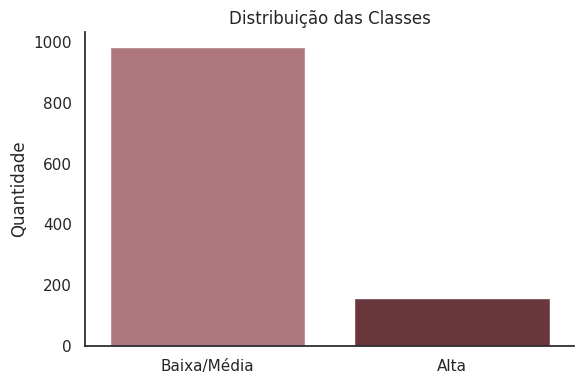

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="quality_binary",
    hue="quality_binary",
    palette=[VINHO_CLARO, VINHO],
    legend=False
)

plt.xticks([0,1], ["Baixa/Média", "Alta"])
plt.title("Distribuição das Classes")
plt.xlabel("")
plt.ylabel("Quantidade")
sns.despine()
plt.tight_layout()
plt.show()


In [11]:
df["quality_binary"].value_counts(normalize=True)*100

,proportion
quality_binary,
0,86.089239
1,13.910761


## Análise de outliers

Os boxplots ajudam a identificar valores extremos e diferenças de dispersão entre as variáveis.


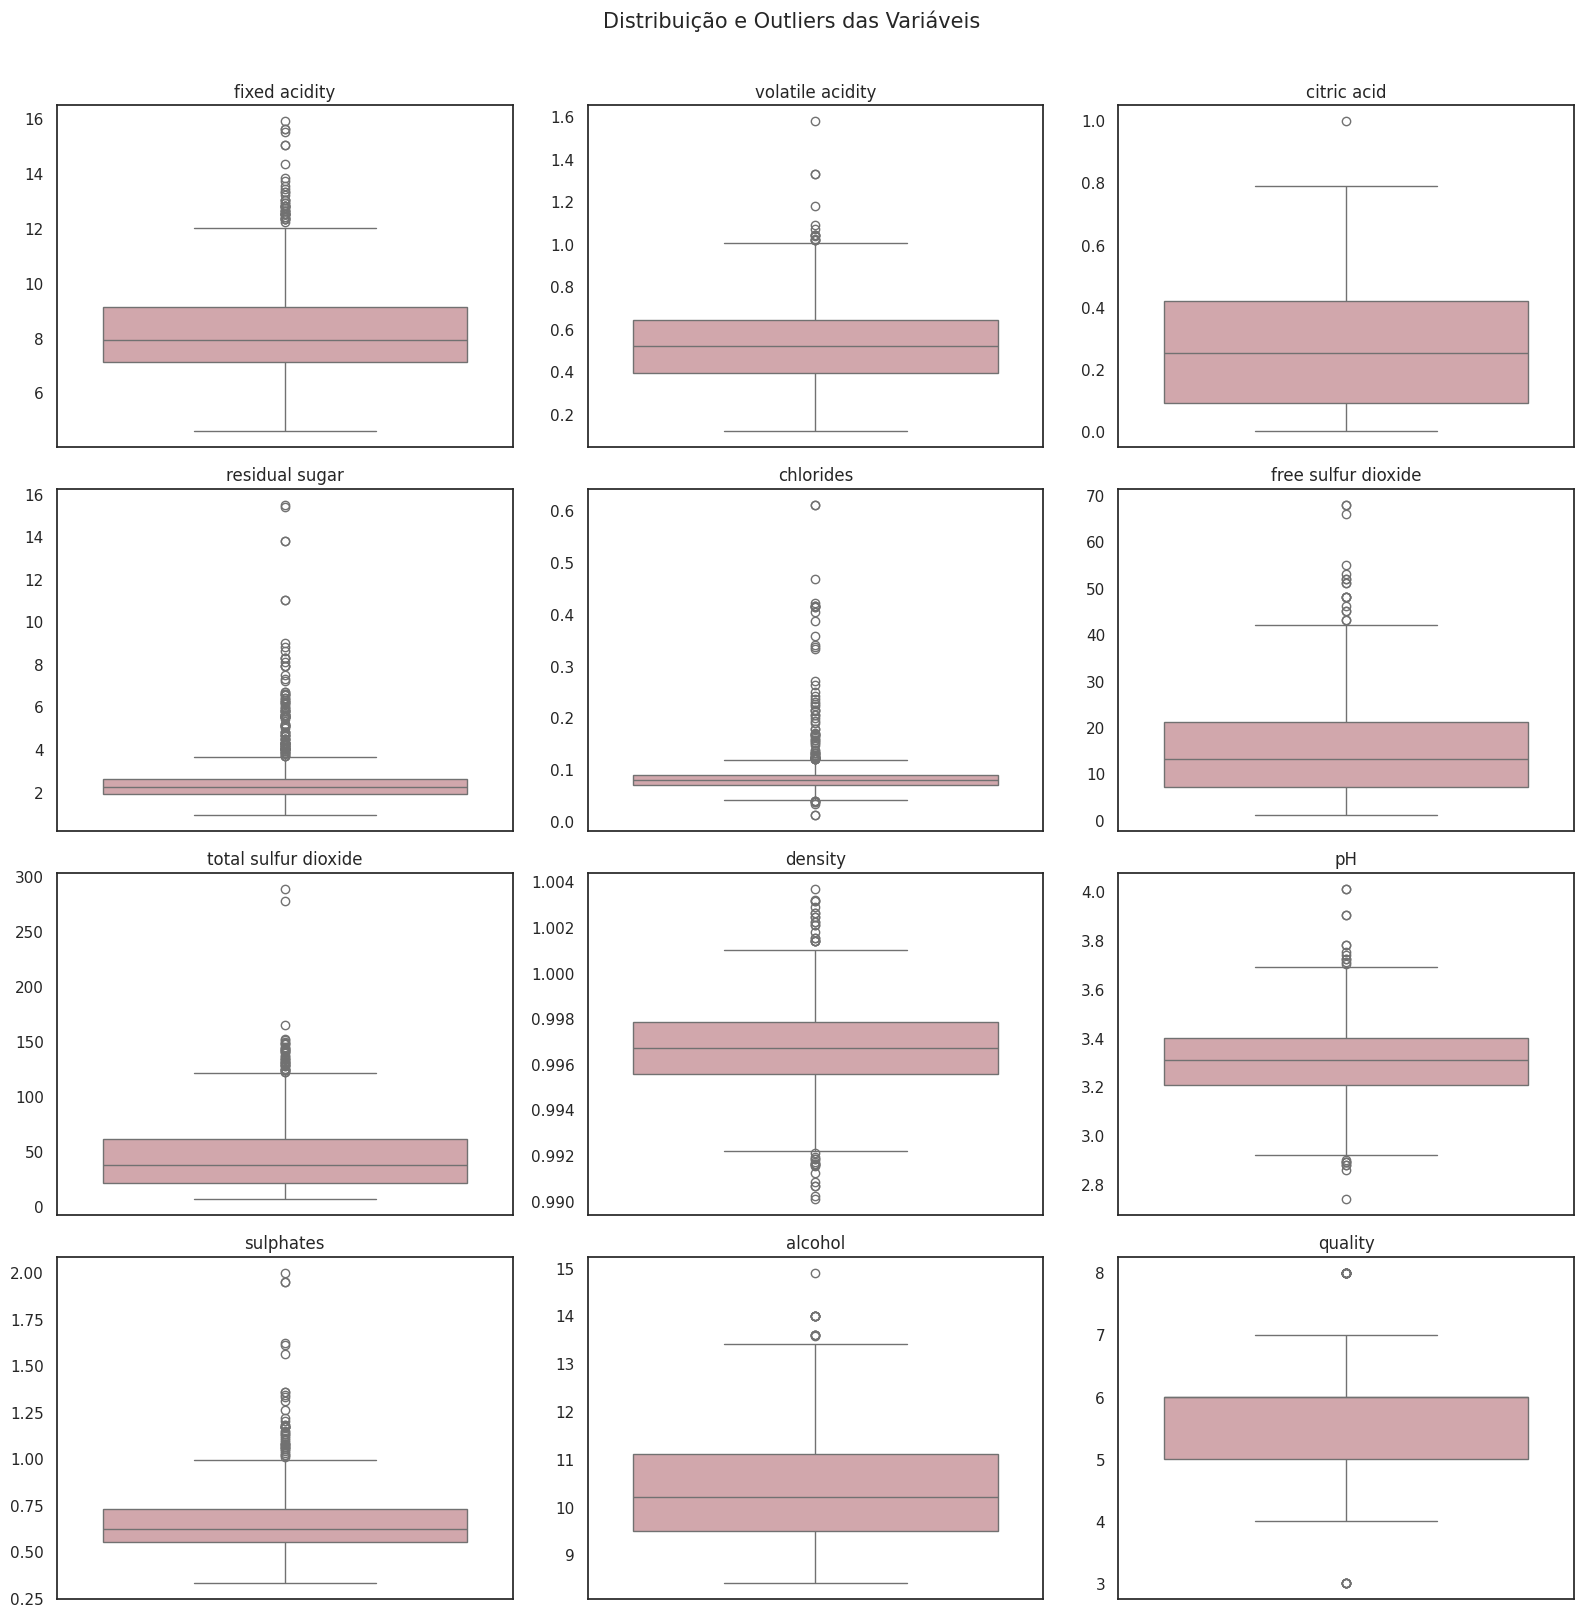

In [12]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols_plot = [c for c in numeric_cols if c not in ["Id", "quality_binary"]]

n_cols = 3
n_rows = int(np.ceil(len(numeric_cols_plot) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, numeric_cols_plot):
    sns.boxplot(y=df[col], color=ROSE, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[len(numeric_cols_plot):]:
    ax.remove()

plt.suptitle("Distribuição e Outliers das Variáveis", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()


## Feature Engineering

Além das variáveis originais, podem ser criadas relações entre características físico-químicas para explorar possíveis padrões associados à qualidade.


In [13]:
df["sulfur_ratio"] = df["free sulfur dioxide"] / df["total sulfur dioxide"].replace(0, np.nan)
df["acidity_ratio"] = df["fixed acidity"] / df["volatile acidity"].replace(0, np.nan)
df["alcohol_density"] = df["alcohol"] / df["density"].replace(0, np.nan)
df["total_acidity"] = df["fixed acidity"] + df["citric acid"]
df["sulfur_difference"] = df["total sulfur dioxide"] - df["free sulfur dioxide"]
df["alcohol_per_sugar"] = df["alcohol"] / df["residual sugar"].replace(0, np.nan)

df.replace([np.inf, -np.inf], np.nan, inplace=True)

df[[
    "sulfur_ratio",
    "acidity_ratio",
    "alcohol_density",
    "total_acidity",
    "sulfur_difference",
    "alcohol_per_sugar"
]].describe().T


,count,mean,std,min,25%,50%,75%,max
sulfur_ratio,1143.0,0.380418,0.154112,0.022727,0.257473,0.375000,0.478261,0.857143
acidity_ratio,1143.0,18.087713,9.266447,4.807692,11.612903,15.102041,22.041667,74.166667
alcohol_density,1143.0,10.477443,1.096987,8.393285,9.536716,10.208780,11.160139,14.935846
total_acidity,1143.0,8.579475,1.885614,4.750000,7.250000,8.190000,9.490000,16.550000
sulfur_difference,1143.0,30.299213,27.119049,3.000000,12.000000,21.000000,39.000000,251.500000
alcohol_per_sugar,1143.0,4.686071,1.391814,0.584416,3.921538,4.736842,5.472136,14.111111


# Análises Comparativas das Variáveis

A seguir, analisamos quais características apresentam maior associação com a qualidade e como suas distribuições mudam entre vinhos de baixa/média e alta qualidade.


## 1. Correlação entre as variáveis

A matriz de correlação ajuda a identificar relações lineares entre as características físico-químicas e a qualidade.


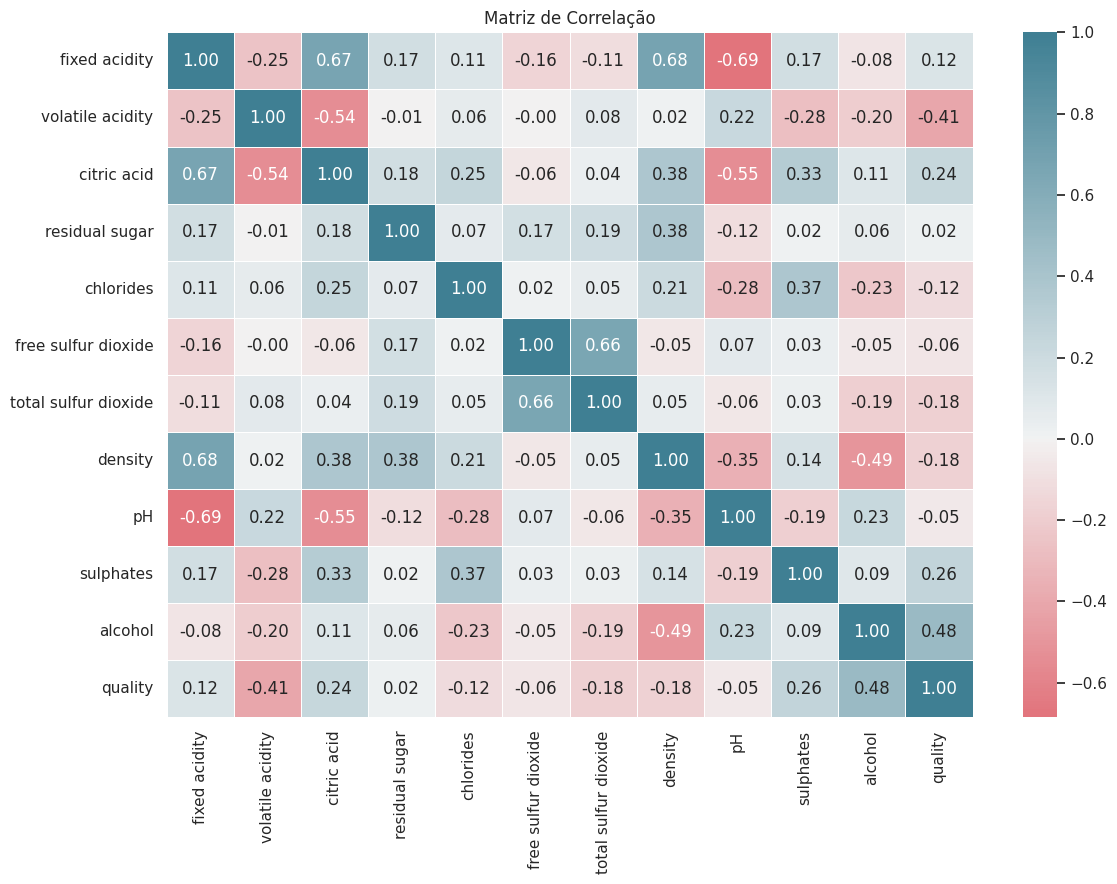

In [14]:
corr_cols = [
    "fixed acidity", "volatile acidity", "citric acid",
    "residual sugar", "chlorides", "free sulfur dioxide",
    "total sulfur dioxide", "density", "pH",
    "sulphates", "alcohol", "quality"
]

corr = df[corr_cols].corr()

plt.figure(figsize=(12,9))
sns.heatmap(
    corr,
    cmap=sns.diverging_palette(10, 220, as_cmap=True),
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matriz de Correlação")
plt.tight_layout()
plt.show()


## 2. Variáveis mais correlacionadas com a qualidade

Esse ranking facilita a identificação das características com maior associação positiva ou negativa com `quality`.


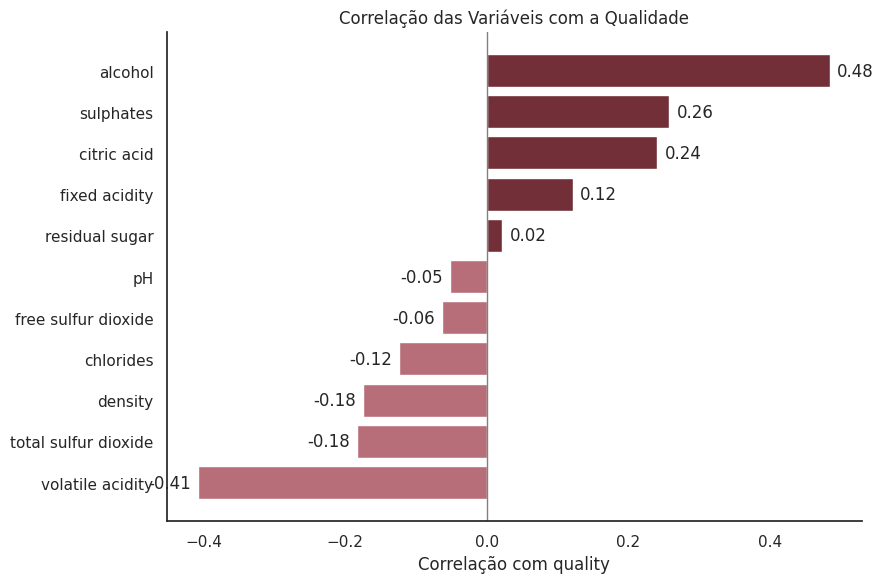

In [15]:
corr_quality = (
    df[corr_cols]
    .corr()["quality"]
    .drop("quality")
    .sort_values()
)

plt.figure(figsize=(9,6))
bars = plt.barh(
    corr_quality.index,
    corr_quality.values,
    color=[VINHO_CLARO if x < 0 else VINHO for x in corr_quality.values]
)

plt.axvline(0, color="gray", linewidth=1)
plt.title("Correlação das Variáveis com a Qualidade")
plt.xlabel("Correlação com quality")
plt.ylabel("")

for bar, value in zip(bars, corr_quality.values):
    plt.text(
        value + (0.01 if value >= 0 else -0.01),
        bar.get_y() + bar.get_height()/2,
        f"{value:.2f}",
        va="center",
        ha="left" if value >= 0 else "right"
    )

sns.despine()
plt.tight_layout()
plt.show()


## 3. Comparação das médias por classe

Comparamos a média de cada variável entre vinhos de baixa/média qualidade e alta qualidade.


In [16]:
features_originais = [
    "fixed acidity", "volatile acidity", "citric acid",
    "residual sugar", "chlorides", "free sulfur dioxide",
    "total sulfur dioxide", "density", "pH",
    "sulphates", "alcohol"
]

medias_classe = (
    df.groupby("quality_binary")[features_originais]
      .mean()
      .T
)

medias_classe.columns = ["Baixa/Média", "Alta"]

display(medias_classe.round(3))


,Baixa/Média,Alta
fixed acidity,8.225,8.847
volatile acidity,0.553,0.395
citric acid,0.249,0.391
residual sugar,2.497,2.748
chlorides,0.089,0.075
free sulfur dioxide,15.846,14.189
total sulfur dioxide,47.408,36.673
density,0.997,0.996
pH,3.316,3.282
sulphates,0.643,0.746


## 4. Diferença percentual entre as classes

Mostra quanto a média da classe de alta qualidade difere da classe baixa/média para cada variável.


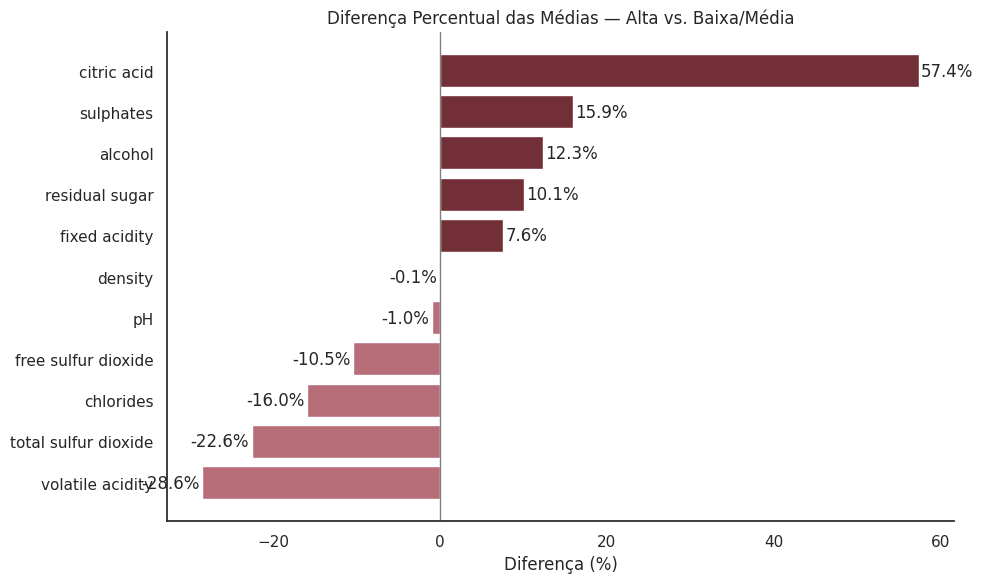

In [17]:
dif_percentual = (
    (medias_classe["Alta"] - medias_classe["Baixa/Média"]) /
    medias_classe["Baixa/Média"] * 100
).sort_values()

plt.figure(figsize=(10,6))
bars = plt.barh(
    dif_percentual.index,
    dif_percentual.values,
    color=[VINHO_CLARO if x < 0 else VINHO for x in dif_percentual.values]
)

plt.axvline(0, color="gray", linewidth=1)
plt.title("Diferença Percentual das Médias — Alta vs. Baixa/Média")
plt.xlabel("Diferença (%)")
plt.ylabel("")

for bar, value in zip(bars, dif_percentual.values):
    plt.text(
        value + (0.3 if value >= 0 else -0.3),
        bar.get_y() + bar.get_height()/2,
        f"{value:.1f}%",
        va="center",
        ha="left" if value >= 0 else "right"
    )

sns.despine()
plt.tight_layout()
plt.show()


## 5. Boxplots das principais variáveis por classe

Esses gráficos mostram diferenças de mediana, dispersão e outliers entre os grupos.


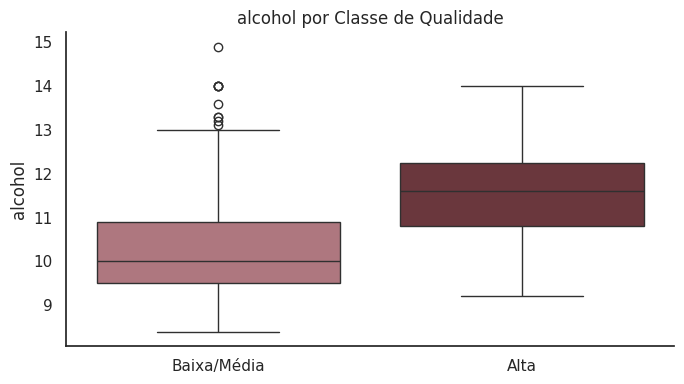

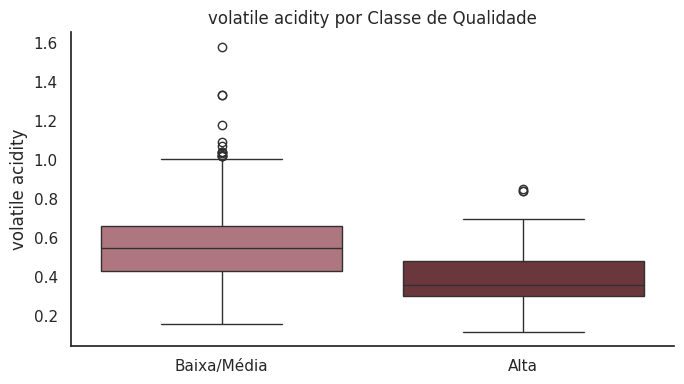

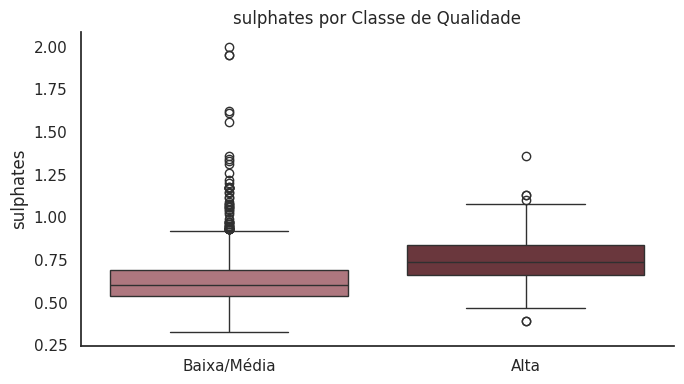

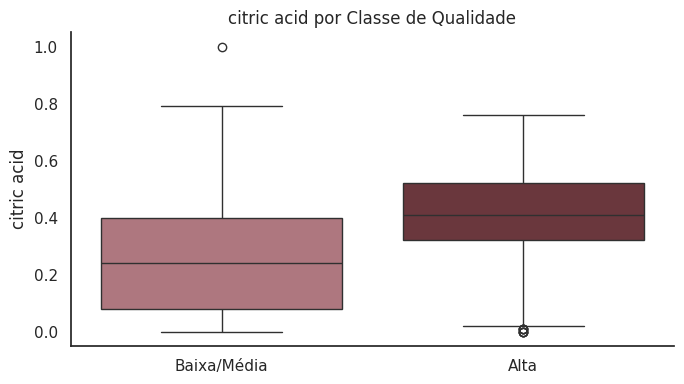

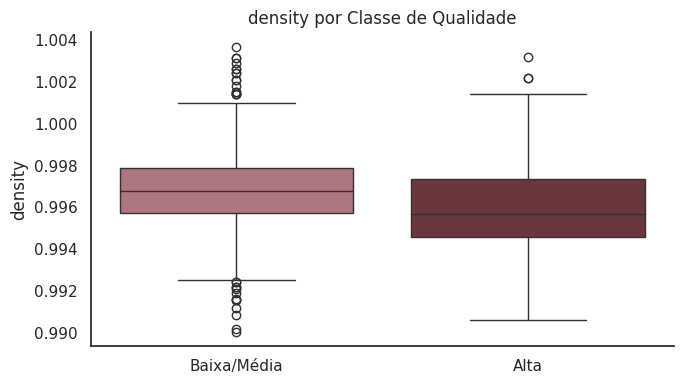

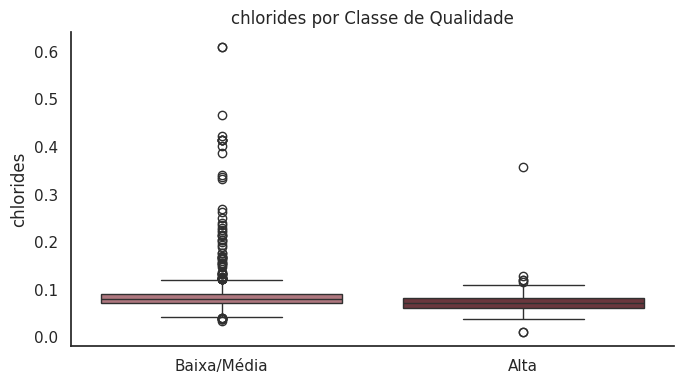

In [18]:
principais = [
    "alcohol",
    "volatile acidity",
    "sulphates",
    "citric acid",
    "density",
    "chlorides"
]

for col in principais:
    plt.figure(figsize=(7,4))
    sns.boxplot(
        data=df,
        x="quality_binary",
        y=col,
        hue="quality_binary",
        palette=[VINHO_CLARO, VINHO],
        legend=False
    )
    plt.xticks([0,1], ["Baixa/Média", "Alta"])
    plt.title(f"{col} por Classe de Qualidade")
    plt.xlabel("")
    plt.ylabel(col)
    sns.despine()
    plt.tight_layout()
    plt.show()


## 6. Distribuição de Alcohol por classe

O teor alcoólico costuma apresentar uma relação visual importante com a qualidade.


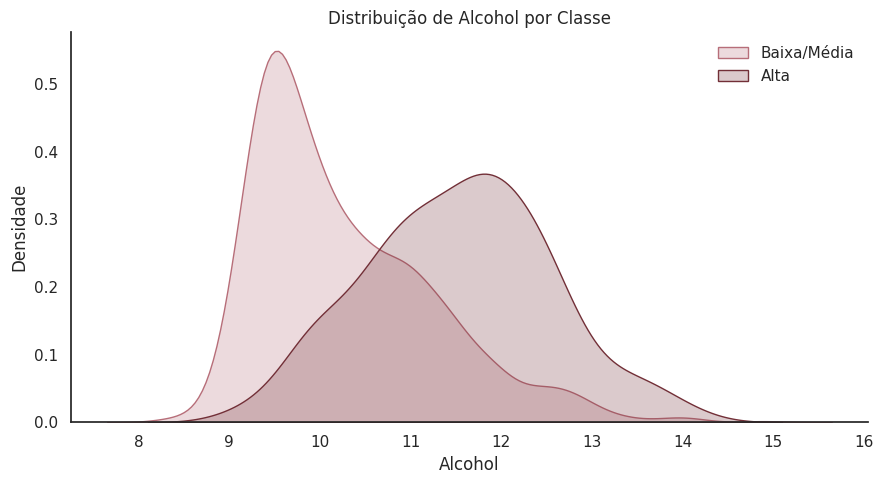

In [19]:
plt.figure(figsize=(9,5))

sns.kdeplot(
    data=df[df["quality_binary"] == 0],
    x="alcohol",
    fill=True,
    alpha=0.25,
    color=VINHO_CLARO,
    label="Baixa/Média"
)

sns.kdeplot(
    data=df[df["quality_binary"] == 1],
    x="alcohol",
    fill=True,
    alpha=0.25,
    color=VINHO,
    label="Alta"
)

plt.title("Distribuição de Alcohol por Classe")
plt.xlabel("Alcohol")
plt.ylabel("Densidade")
plt.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()


## 7. Volatile Acidity × Alcohol

A combinação entre teor alcoólico e acidez volátil permite observar a separação entre as classes em duas variáveis relevantes.


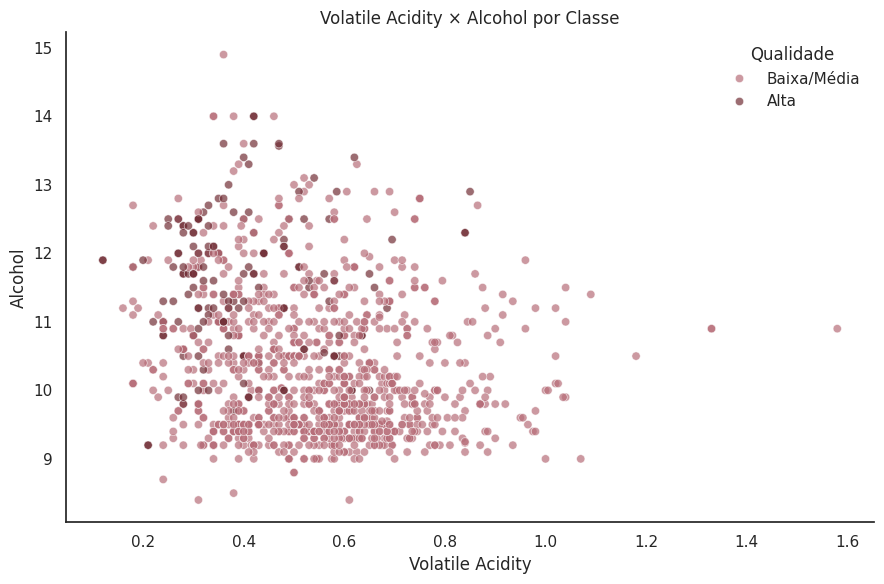

In [20]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="volatile acidity",
    y="alcohol",
    hue="quality_binary",
    palette={0: VINHO_CLARO, 1: VINHO},
    alpha=0.7
)

plt.title("Volatile Acidity × Alcohol por Classe")
plt.xlabel("Volatile Acidity")
plt.ylabel("Alcohol")

handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(
    handles=handles,
    labels=["Baixa/Média", "Alta"],
    title="Qualidade",
    frameon=False
)

sns.despine()
plt.tight_layout()
plt.show()


## 8. Sulphates × Alcohol

Essa visão permite verificar se vinhos de alta qualidade tendem a se concentrar em regiões específicas dessas duas características.


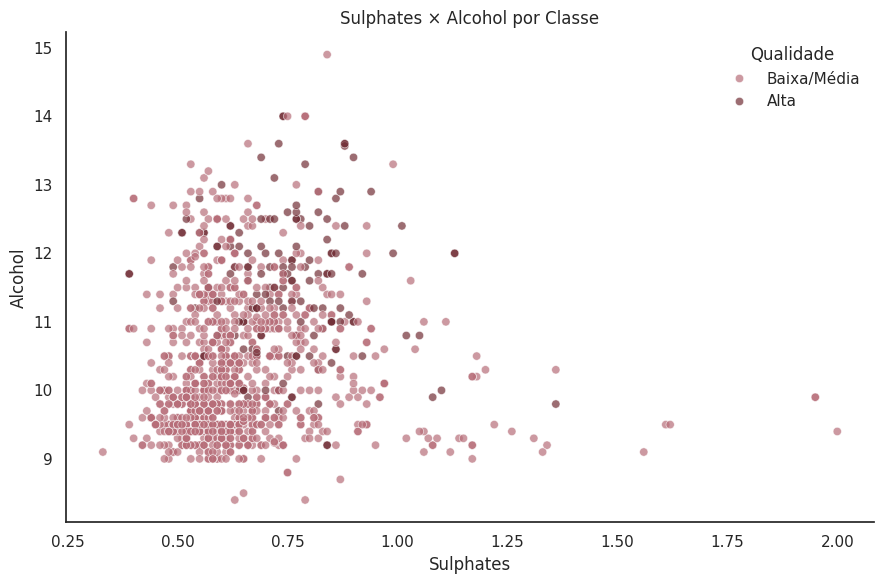

In [21]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="sulphates",
    y="alcohol",
    hue="quality_binary",
    palette={0: VINHO_CLARO, 1: VINHO},
    alpha=0.7
)

plt.title("Sulphates × Alcohol por Classe")
plt.xlabel("Sulphates")
plt.ylabel("Alcohol")

handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(
    handles=handles,
    labels=["Baixa/Média", "Alta"],
    title="Qualidade",
    frameon=False
)

sns.despine()
plt.tight_layout()
plt.show()


## 9. Distribuição das principais variáveis por nota

Aqui analisamos como as medianas evoluem ao longo das notas originais de qualidade.


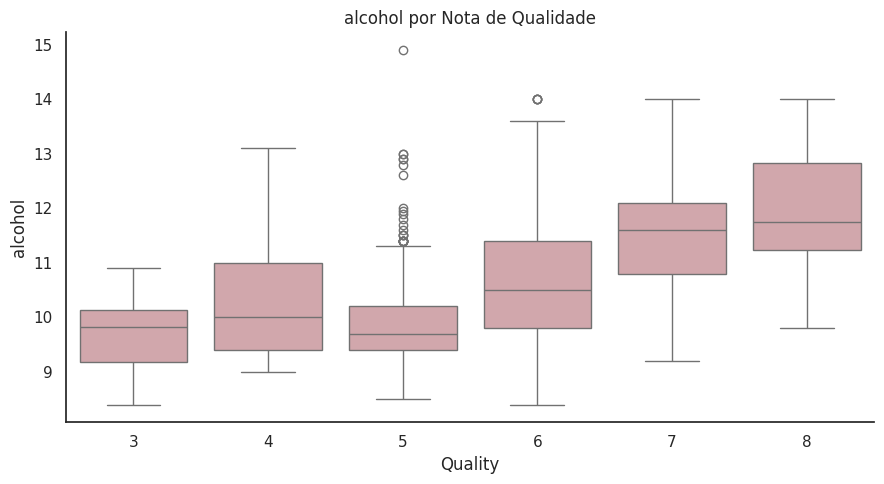

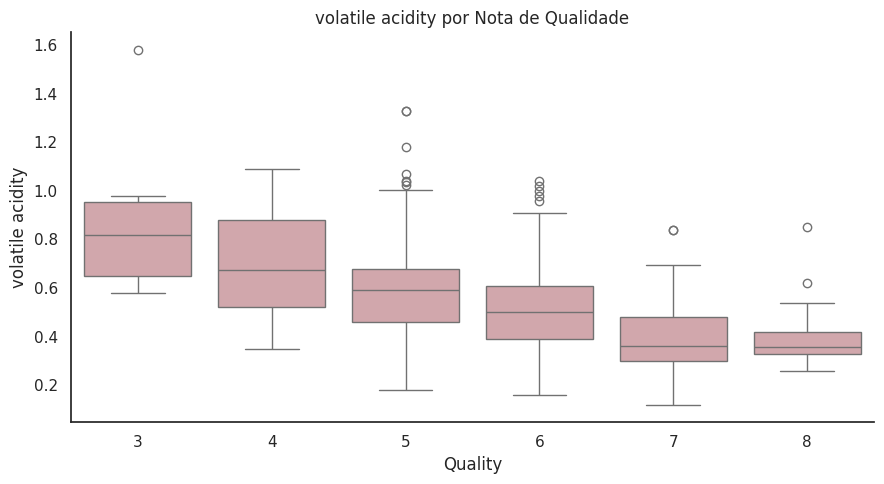

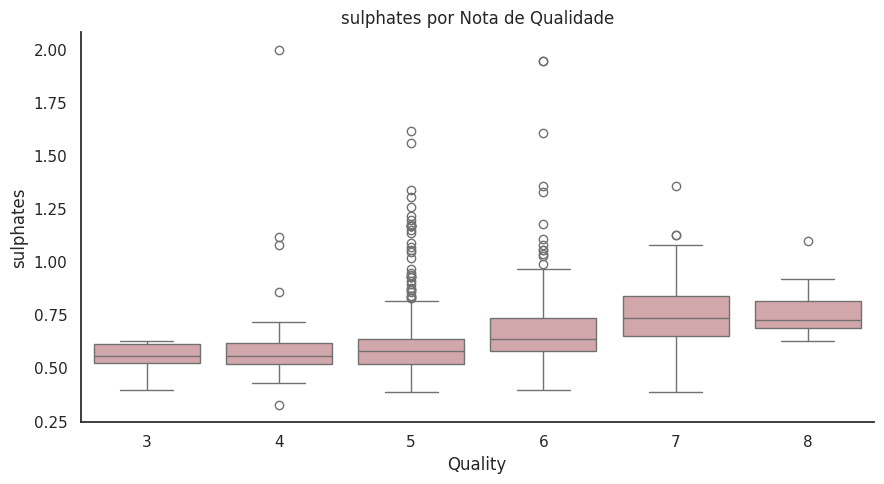

In [22]:
for col in ["alcohol", "volatile acidity", "sulphates"]:
    plt.figure(figsize=(9,5))
    sns.boxplot(
        data=df,
        x="quality",
        y=col,
        color=ROSE
    )
    plt.title(f"{col} por Nota de Qualidade")
    plt.xlabel("Quality")
    plt.ylabel(col)
    sns.despine()
    plt.tight_layout()
    plt.show()


## 10. Correlação das variáveis criadas com a qualidade

As variáveis derivadas ajudam a explorar relações que não aparecem diretamente nas features originais.


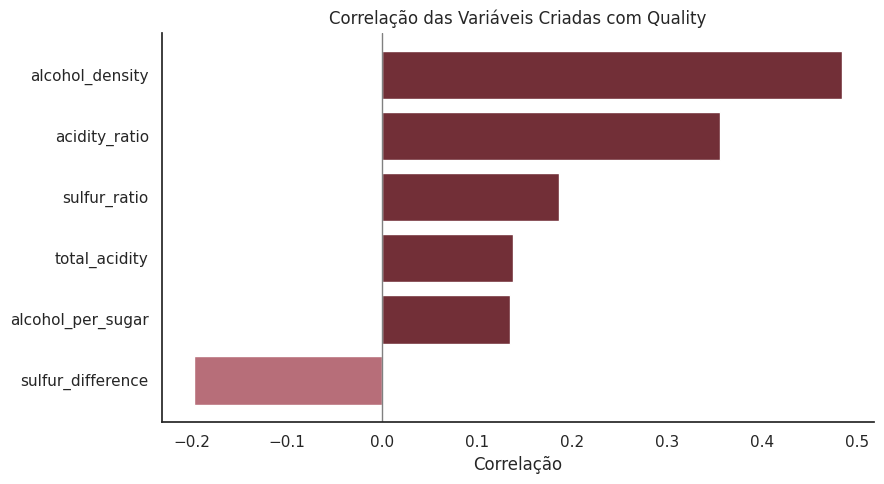

,Correlação
sulfur_difference,-0.198
alcohol_per_sugar,0.135
total_acidity,0.138
sulfur_ratio,0.187
acidity_ratio,0.355
alcohol_density,0.484


In [23]:
features_engineered = [
    "sulfur_ratio",
    "acidity_ratio",
    "alcohol_density",
    "total_acidity",
    "sulfur_difference",
    "alcohol_per_sugar"
]

corr_engineered = (
    df[features_engineered + ["quality"]]
    .corr()["quality"]
    .drop("quality")
    .sort_values()
)

plt.figure(figsize=(9,5))
bars = plt.barh(
    corr_engineered.index,
    corr_engineered.values,
    color=[VINHO_CLARO if x < 0 else VINHO for x in corr_engineered.values]
)

plt.axvline(0, color="gray", linewidth=1)
plt.title("Correlação das Variáveis Criadas com Quality")
plt.xlabel("Correlação")
plt.ylabel("")
sns.despine()
plt.tight_layout()
plt.show()

display(corr_engineered.to_frame("Correlação").round(3))


# Principais Insights

A análise exploratória permite identificar quais variáveis apresentam maior associação com a qualidade e quais diferenças são mais visíveis entre as classes.

Em geral, vale observar especialmente:

- variáveis com maior correlação absoluta com `quality`;
- diferenças de distribuição entre as classes;
- presença de outliers;
- possíveis relações conjuntas entre `alcohol`, `volatile acidity`, `sulphates` e outras características relevantes;
- comportamento das variáveis derivadas criadas no Feature Engineering.

Esses resultados ajudam a justificar a seleção de variáveis e o uso de modelos de classificação nas próximas etapas do Tech Challenge.
